# M515A Ethical Issues for AI
## Fairness assessment and mitigation in credit default risk prediction

**Student:** Somesh Ranjan Rout  
**Student ID:** GH1039569  
**Assessment:** Retake  
**Primary sensitive attribute:** Sex, as coded in the source dataset  
**Primary fairness objective:** True positive rate parity

### Research question

Do female and male customers who did not default in the observed month have a comparable opportunity to receive a favourable model prediction, and can any measured true positive rate disparity be reduced without an unacceptable loss in predictive performance?

### Scope

This notebook evaluates group disparities in a one month credit default risk model. The model is treated as decision support for trained reviewers. It is not presented as an autonomous credit approval system. The source label records observed default behaviour, not a complete or causal measure of individual creditworthiness.

> **Student review required:** Run every cell from a clean kernel, inspect every result, complete each section labelled **Student interpretation required**, and retain only claims that you can explain and defend independently.


## Executive summary drafting template

Complete this section after the final test evaluation. Keep it between 150 and 250 words and include the following points.

1. The business problem and the role of the model.
2. The dataset, target, and sensitive attribute.
3. The selected baseline model and its principal test performance values.
4. The baseline fairness disparity that motivated mitigation.
5. The mitigation method and fairness constraint.
6. The exact improvement in the primary fairness metric.
7. The cost in accuracy and balanced accuracy.
8. Any important metric that worsened.
9. The main deployment limitation and recommendation.

Do not describe the system as completely fair, unbiased, legally compliant, or ready for autonomous deployment. Quantitative parity addresses only the measured definition on the evaluated data.


## Assessment mapping and contents

| Assessment requirement | Notebook section |
|---|---|
| Business problem, organisational benefit, data collection, and machine learning formulation | Sections 1 and 2 |
| Ethical concerns and evidence of model disparity | Sections 3, 5, and 9 |
| Alternative mitigation approaches and justified selection | Section 10 |
| Applied mitigation and before versus after results | Sections 11 and 12 |
| Strengths, limitations, business implications, and recommendations | Section 14 |
| Reproducibility and evidence trail | Sections 15 and 16 |

### Contents

1. Business problem and machine learning formulation  
2. Dataset source, data collection, and scope  
3. Ethical concerns and harm definition  
4. Environment and reproducibility setup  
5. Data loading, quality checks, and exploratory analysis  
6. Feature, target, and sensitive attribute definition  
7. Training, validation, and test design  
8. Baseline model comparison and selection  
9. Baseline fairness audit  
10. Mitigation alternatives and selected approach  
11. Post processing mitigation  
12. Final test evaluation  
13. Robustness analysis  
14. Final discussion and recommendations  
15. Model card and reproducibility checklist  
16. References


# 1. Business problem and machine learning formulation

A financial institution may use a default risk model to prioritise the review of existing credit card customers. Manual review can be slow and inconsistent, while a model can process a large number of records in a repeatable way. The model output must nevertheless remain one input to a wider review process because historical data does not contain every factor required for a responsible credit decision.

The task is formulated as supervised binary classification. The source target records whether a customer defaulted in the following month. For this study, the favourable label is defined as:

\[
Y = 1 \quad \text{when the customer did not default in the following month}
\]

\[
Y = 0 \quad \text{when the customer defaulted in the following month}
\]

This orientation makes the true positive rate directly relevant to an allocation harm. It measures the proportion of customers with an observed no default outcome who receive a favourable prediction.

### Error costs

| Error | Meaning in this study | Potential consequence |
|---|---|---|
| False positive | A customer who defaulted receives a favourable prediction | Financial loss, unsuitable credit exposure, and possible customer over indebtedness |
| False negative | A customer who did not default receives an unfavourable prediction | Unnecessary restriction, delayed access, lost business, and an allocation harm |

### Intended use

The intended use is risk triage and decision support. A trained reviewer should consider additional affordability, income, debt, identity, fraud, legal, and product specific evidence before a final decision. The model should not replace explanation, appeal, or human oversight.

## Student interpretation required

Add a concise paragraph explaining:

1. The precise business decision being supported.
2. Why the institution and customers may benefit.
3. Which error is most important in your selected fairness analysis and why.
4. Why the model is not a complete credit approval system.


# 2. Dataset source, data collection, and scope

**Dataset:** Default of Credit Card Clients  
**Repository:** UCI Machine Learning Repository  
**Dataset identifier:** 350  
**DOI:** 10.24432/C55S3H  
**Source page:** https://archive.ics.uci.edu/dataset/350/default

The dataset contains 30,000 customer records and 23 explanatory variables. It describes credit card clients in Taiwan and includes credit limits, demographic codes, repayment status, bill amounts, payment amounts, and default in the following month. The records relate to 2005. These characteristics make the dataset relevant to default prediction, but they also limit transfer to another country, product, population, or economic period.

## Dataset eligibility checkpoint

The assessment requires a dataset that was not used in the module exercises.

> **Student confirmation required:** State how you verified that this dataset was not used in the exercises. Do not submit until this is confirmed.

## Data collection plan for a real organisation

A real deployment would require a documented collection process covering:

1. A defined prediction date and outcome window.
2. Lawful, necessary, and proportionate feature collection.
3. Data provenance, quality controls, retention periods, and access permissions.
4. Clear separation between features available at decision time and information recorded later.
5. Representative coverage across customer groups and products.
6. Reliable outcome labels and documented policy changes.
7. Secure collection of sensitive attributes for legitimate auditing where permitted.
8. A route for explanation, correction, review, and appeal.

The present dataset is observational and does not include every variable required for responsible lending. It also does not establish that past outcomes were free from structural or measurement bias.


# 3. Ethical concerns and harm definition

Fairness must be linked to a defined harm rather than treated as a single universal number.

| Ethical concern | Relevant question | Evidence used in this notebook |
|---|---|---|
| Justice | Do groups with the favourable observed outcome receive comparable opportunities? | True positive rate by group and equal opportunity difference |
| Nonmaleficence | Which group experiences more incorrect unfavourable predictions? | False negative rate by group |
| Financial safety | Which group experiences more incorrect favourable predictions? | False positive rate by group |
| Accountability | Who is responsible for monitoring, overrides, and appeals? | Governance requirements and audit trail |
| Transparency | Can a person understand and challenge the decision process? | Explanation, review, and appeal requirements |
| Privacy | Is sensitive information protected and used only for legitimate purposes? | Access, purpose, retention, and security controls |

## Primary harm

The primary measured harm is an incorrect unfavourable prediction for a customer who did not default in the observed outcome period. This is represented by the false negative rate. Comparing true positive rates across groups assesses whether customers with the favourable observed label have similar opportunities to receive a favourable prediction.

## Primary fairness measure

Equal opportunity difference is defined as:

\[
\Delta_{EO} = \max_a P(\hat{Y}=1 \mid Y=1, A=a)
             - \min_a P(\hat{Y}=1 \mid Y=1, A=a)
\]

A value closer to zero indicates greater true positive rate parity under this definition. It does not establish individual fairness, causal discrimination, legal compliance, or the fairness of the historical label.

## Secondary fairness measures

Demographic parity compares overall favourable prediction rates without conditioning on the observed label. It is useful as a diagnostic, but it can conceal differences in error rates and base rates. Equalized odds considers both true positive rate and false positive rate disparities. Selection rate, precision, false positive rate, and false negative rate are therefore reported alongside the primary measure.

## Student interpretation required

Explain why equal opportunity is the primary metric for this study and why demographic parity alone would be insufficient. Also identify the competing harm associated with false positive predictions.


# 4. Environment and reproducibility setup

Run the notebook in Python 3.10 or later. The analysis is designed for recent versions of pandas, scikit learn, Fairlearn, and ucimlrepo.

The installation cell is intentionally commented. Uncomment it only when the packages are missing, then restart the kernel before continuing. Remove failed installation output before submission.


In [29]:
# Uncomment and run only when the required packages are not already installed.
%pip install -q "pandas>=2.2" "numpy>=1.26" "matplotlib>=3.8" \
    "scikit-learn>=1.5,<1.9" "fairlearn>=0.13,<0.15" \
    "ucimlrepo>=0.0.7" "openpyxl>=3.1" "xlrd>=2.0.1"

In [30]:
from __future__ import annotations

import json
import platform
import warnings
from pathlib import Path
from typing import Callable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from IPython.display import Markdown, display
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

try:
    import fairlearn
    from fairlearn.metrics import (
        MetricFrame,
        count,
        demographic_parity_difference,
        demographic_parity_ratio,
        equal_opportunity_difference,
        equal_opportunity_ratio,
        equalized_odds_difference,
        false_negative_rate,
        false_positive_rate,
        selection_rate,
        true_positive_rate,
    )
    from fairlearn.postprocessing import ThresholdOptimizer, plot_threshold_optimizer
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "Fairlearn is required. Uncomment the installation cell, run it once, "
        "restart the kernel, and rerun the notebook."
    ) from exc

try:
    from ucimlrepo import fetch_ucirepo
except ModuleNotFoundError:
    fetch_ucirepo = None

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", 100)
pd.set_option("display.precision", 4)

print("Python:", platform.python_version())
print("pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)
print("fairlearn:", fairlearn.__version__)


Python: 3.13.15
pandas: 2.2.3
scikit-learn: 1.6.1
fairlearn: 0.14.0


# 5. Data loading, quality checks, and exploratory analysis

The loader first looks for a local dataset file so the repository can remain reproducible after submission. When no local file is available, it uses the official `ucimlrepo` interface.

Recommended local locations are:

1. `data/default_of_credit_card_clients.csv`
2. `data/default_of_credit_card_clients.xls`
3. `default_of_credit_card_clients.csv`
4. `default_of_credit_card_clients.xls`

When using the original Excel file, retain the source file without editing it and document its origin in the repository README.


In [31]:
COLUMN_MAP = {
    "X1": "LIMIT_BAL",
    "X2": "SEX",
    "X3": "EDUCATION",
    "X4": "MARRIAGE",
    "X5": "AGE",
    "X6": "PAY_0",
    "X7": "PAY_2",
    "X8": "PAY_3",
    "X9": "PAY_4",
    "X10": "PAY_5",
    "X11": "PAY_6",
    "X12": "BILL_AMT1",
    "X13": "BILL_AMT2",
    "X14": "BILL_AMT3",
    "X15": "BILL_AMT4",
    "X16": "BILL_AMT5",
    "X17": "BILL_AMT6",
    "X18": "PAY_AMT1",
    "X19": "PAY_AMT2",
    "X20": "PAY_AMT3",
    "X21": "PAY_AMT4",
    "X22": "PAY_AMT5",
    "X23": "PAY_AMT6",
    "Y": "DEFAULT_NEXT_MONTH",
    "DEFAULT_PAYMENT_NEXT_MONTH": "DEFAULT_NEXT_MONTH",
    "DEFAULT_PAYMENT_NEXT_MONTH_": "DEFAULT_NEXT_MONTH",
}

LOCAL_DATA_CANDIDATES = [
    Path("data/default_of_credit_card_clients.csv"),
    Path("data/default_of_credit_card_clients.xls"),
    Path("default_of_credit_card_clients.csv"),
    Path("default_of_credit_card_clients.xls"),
]


def normalise_column_name(value: object) -> str:
    text = str(value).strip().replace("\n", " ")
    return "_".join(text.upper().split())


def normalise_source_frame(frame: pd.DataFrame) -> pd.DataFrame:
    output = frame.copy()
    output.columns = [normalise_column_name(c) for c in output.columns]
    output = output.rename(columns=COLUMN_MAP)
    if "ID" in output.columns:
        output = output.drop(columns="ID")
    return output


def load_credit_data() -> tuple[pd.DataFrame, str, pd.DataFrame | None]:
    for path in LOCAL_DATA_CANDIDATES:
        if not path.exists():
            continue
        if path.suffix.lower() == ".csv":
            raw = pd.read_csv(path)
        else:
            raw = pd.read_excel(path, sheet_name="Data", header=1)
        return normalise_source_frame(raw), f"Local file: {path}", None

    if fetch_ucirepo is None:
        raise FileNotFoundError(
            "No local dataset was found and ucimlrepo is unavailable. "
            "Place the UCI source file in the data folder or install ucimlrepo."
        )

    dataset = fetch_ucirepo(id=350)
    features = normalise_source_frame(dataset.data.features.copy())
    target = dataset.data.targets.copy()
    target.columns = [normalise_column_name(c) for c in target.columns]
    target = target.rename(columns=COLUMN_MAP)
    target_column = target.columns[0]
    features["DEFAULT_NEXT_MONTH"] = pd.to_numeric(
        target[target_column], errors="raise"
    ).astype(int).to_numpy()
    variables = dataset.variables.copy() if hasattr(dataset, "variables") else None
    return features, "UCI Machine Learning Repository via ucimlrepo", variables


source_frame, DATA_SOURCE_USED, source_variables = load_credit_data()

if "DEFAULT_NEXT_MONTH" not in source_frame.columns:
    target_candidates = [
        c for c in source_frame.columns
        if "DEFAULT" in c and "MONTH" in c
    ]
    if len(target_candidates) != 1:
        raise KeyError(
            "The default target column could not be identified. "
            f"Candidates found: {target_candidates}"
        )
    source_frame = source_frame.rename(
        columns={target_candidates[0]: "DEFAULT_NEXT_MONTH"}
    )

required_columns = {
    "LIMIT_BAL", "SEX", "EDUCATION", "MARRIAGE", "AGE",
    "PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6",
    "BILL_AMT1", "BILL_AMT2", "BILL_AMT3", "BILL_AMT4",
    "BILL_AMT5", "BILL_AMT6", "PAY_AMT1", "PAY_AMT2",
    "PAY_AMT3", "PAY_AMT4", "PAY_AMT5", "PAY_AMT6",
    "DEFAULT_NEXT_MONTH",
}
missing_required = required_columns.difference(source_frame.columns)
if missing_required:
    raise KeyError(f"Required columns are missing: {sorted(missing_required)}")

df = source_frame.copy()
df["DEFAULT_NEXT_MONTH"] = pd.to_numeric(
    df["DEFAULT_NEXT_MONTH"], errors="raise"
).astype(int)
df["NO_DEFAULT_NEXT_MONTH"] = 1 - df["DEFAULT_NEXT_MONTH"]

print("Data source used:", DATA_SOURCE_USED)
print("Dataset shape including derived label:", df.shape)
display(df.head())

if source_variables is not None:
    display(source_variables.head(30))


Data source used: UCI Machine Learning Repository via ucimlrepo
Dataset shape including derived label: (30000, 25)


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT_NEXT_MONTH,NO_DEFAULT_NEXT_MONTH
0,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1,0
1,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1,0
2,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0,1
3,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0,1
4,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0,1


,name,role,type,demographic,description,units,missing_values
0,ID,ID,Integer,None,None,None,no
1,X1,Feature,Integer,None,LIMIT_BAL,None,no
2,X2,Feature,Integer,Sex,SEX,None,no
3,X3,Feature,Integer,Education Level,EDUCATION,None,no
4,X4,Feature,Integer,Marital Status,MARRIAGE,None,no
5,X5,Feature,Integer,Age,AGE,None,no
6,X6,Feature,Integer,None,PAY_0,None,no
7,X7,Feature,Integer,None,PAY_2,None,no
8,X8,Feature,Integer,None,PAY_3,None,no
9,X9,Feature,Integer,None,PAY_4,None,no


In [32]:
quality_summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_count": df.isna().sum(),
    "unique_values": df.nunique(dropna=False),
})

display(quality_summary)

print("Total missing values:", int(df.isna().sum().sum()))
print("Exact duplicate rows after ID removal:", int(df.duplicated().sum()))
print("Target values:", sorted(df["DEFAULT_NEXT_MONTH"].unique().tolist()))
print("Sex codes:", sorted(df["SEX"].dropna().unique().tolist()))
print("Education codes:", sorted(df["EDUCATION"].dropna().unique().tolist()))
print("Marriage codes:", sorted(df["MARRIAGE"].dropna().unique().tolist()))
print(
    "Repayment status codes:",
    sorted(pd.unique(df[["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]].values.ravel()).tolist()),
)


,dtype,missing_count,unique_values
LIMIT_BAL,int64,0,81
SEX,int64,0,2
EDUCATION,int64,0,7
MARRIAGE,int64,0,4
AGE,int64,0,56
PAY_0,int64,0,11
PAY_2,int64,0,11
PAY_3,int64,0,11
PAY_4,int64,0,11
PAY_5,int64,0,10


Total missing values: 0
Exact duplicate rows after ID removal: 35
Target values: [0, 1]
Sex codes: [1, 2]
Education codes: [0, 1, 2, 3, 4, 5, 6]
Marriage codes: [0, 1, 2, 3]
Repayment status codes: [-2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8]


## Data quality decisions

The official documentation defines sex codes 1 and 2, education codes 1 to 4, and marital status codes 1 to 3. Common copies of the dataset contain additional undocumented values. These records are retained and labelled as `Unknown` rather than silently assigned to a documented category. Repayment status codes are handled as categories in the primary pipeline, avoiding an unsupported assumption that every adjacent code has an equal linear distance.

Exact duplicate feature and target rows are reported but are not automatically removed. Repeated customer profiles may be genuine. Removing them without an identifier or provenance evidence could alter group representation and fairness results.

## Student interpretation required

Record the actual missing value count, duplicate count, target values, and undocumented category codes from your execution. Explain whether any row was removed and why.


In [33]:
SEX_MAP = {1: "Male", 2: "Female"}
EDUCATION_MAP = {
    1: "Graduate school",
    2: "University",
    3: "High school",
    4: "Other",
    0: "Unknown",
    5: "Unknown",
    6: "Unknown",
}
MARRIAGE_MAP = {
    1: "Married",
    2: "Single",
    3: "Other",
    0: "Unknown",
}
PAY_STATUS_COLUMNS = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]


df["SEX_GROUP"] = df["SEX"].map(SEX_MAP)
df["EDUCATION_CAT"] = df["EDUCATION"].map(EDUCATION_MAP).fillna("Unknown")
df["MARRIAGE_CAT"] = df["MARRIAGE"].map(MARRIAGE_MAP).fillna("Unknown")

for column in PAY_STATUS_COLUMNS:
    df[f"{column}_CAT"] = df[column].astype("Int64").astype(str)

if df["SEX_GROUP"].isna().any():
    unexpected = sorted(df.loc[df["SEX_GROUP"].isna(), "SEX"].unique().tolist())
    raise ValueError(f"Unexpected sex codes found: {unexpected}")

category_check = (
    df[["SEX", "SEX_GROUP", "EDUCATION", "EDUCATION_CAT", "MARRIAGE", "MARRIAGE_CAT"]]
    .drop_duplicates()
    .sort_values(["SEX", "EDUCATION", "MARRIAGE"])
)
display(category_check)


,SEX,SEX_GROUP,EDUCATION,EDUCATION_CAT,MARRIAGE,MARRIAGE_CAT
27155,1,Male,0,Unknown,1,Married
5945,1,Male,0,Unknown,2,Single
24443,1,Male,1,Graduate school,0,Unknown
17,1,Male,1,Graduate school,1,Married
5,1,Male,1,Graduate school,2,Single
710,1,Male,1,Graduate school,3,Other
24721,1,Male,2,University,0,Unknown
4,1,Male,2,University,1,Married
13,1,Male,2,University,2,Single
531,1,Male,2,University,3,Other


## Exploratory analysis before modelling

This section separates disparities already present in the observed labels from disparities introduced or amplified by the model. A raw difference between groups is evidence of disparity, not proof of causal or unlawful discrimination.


In [34]:
label_summary = pd.DataFrame({
    "count": df["NO_DEFAULT_NEXT_MONTH"].value_counts().sort_index(),
    "proportion": df["NO_DEFAULT_NEXT_MONTH"].value_counts(normalize=True).sort_index(),
})
label_summary.index = ["Default next month", "No default next month"]

group_summary = (
    df.groupby("SEX_GROUP", observed=True)
      .agg(
          records=("NO_DEFAULT_NEXT_MONTH", "size"),
          observed_no_default_rate=("NO_DEFAULT_NEXT_MONTH", "mean"),
          mean_credit_limit=("LIMIT_BAL", "mean"),
          median_credit_limit=("LIMIT_BAL", "median"),
          median_age=("AGE", "median"),
      )
)

observed_outcome_table = pd.crosstab(
    df["SEX_GROUP"],
    df["NO_DEFAULT_NEXT_MONTH"],
    margins=True,
).rename(columns={0: "Default", 1: "No default"})

display(label_summary)
display(group_summary)
display(observed_outcome_table)


,count,proportion
Default next month,6636,0.2212
No default next month,23364,0.7788


,records,observed_no_default_rate,mean_credit_limit,median_credit_limit,median_age
SEX_GROUP,,,,,
Female,18112,0.7922,170086.462,150000.0,33.0
Male,11888,0.7583,163519.825,130000.0,35.0


NO_DEFAULT_NEXT_MONTH,Default,No default,All
SEX_GROUP,,,
Female,3763,14349,18112
Male,2873,9015,11888
All,6636,23364,30000


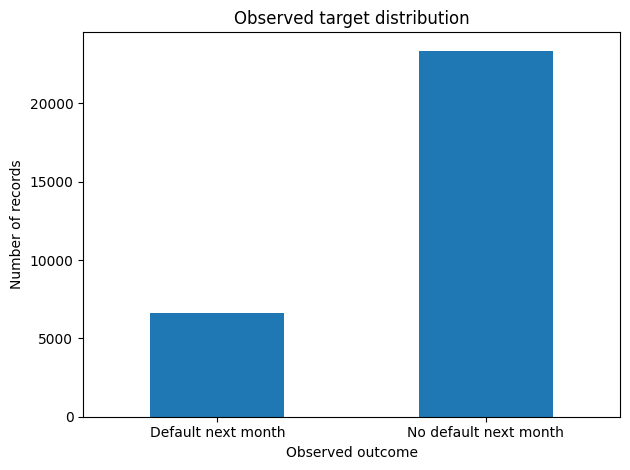

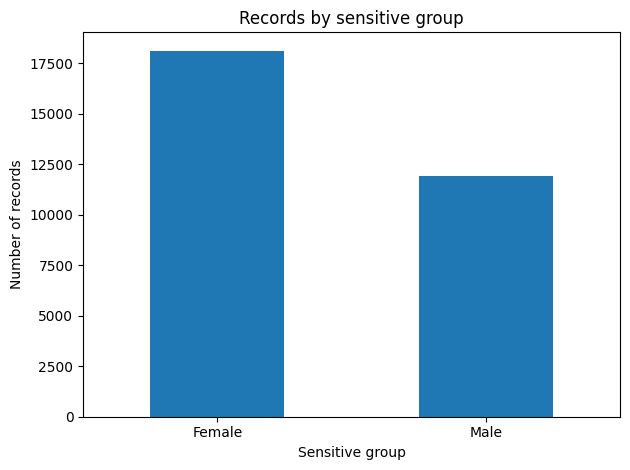

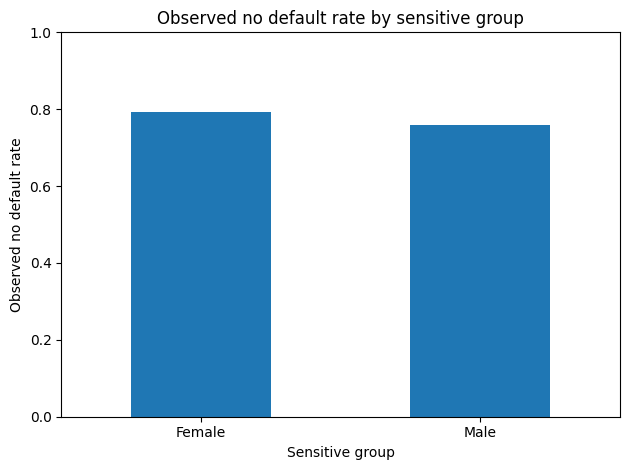

In [35]:
ax = label_summary["count"].plot(
    kind="bar",
    rot=0,
    title="Observed target distribution",
)
ax.set_xlabel("Observed outcome")
ax.set_ylabel("Number of records")
plt.tight_layout()
plt.show()

ax = group_summary["records"].plot(
    kind="bar",
    rot=0,
    title="Records by sensitive group",
)
ax.set_xlabel("Sensitive group")
ax.set_ylabel("Number of records")
plt.tight_layout()
plt.show()

ax = group_summary["observed_no_default_rate"].plot(
    kind="bar",
    rot=0,
    title="Observed no default rate by sensitive group",
)
ax.set_xlabel("Sensitive group")
ax.set_ylabel("Observed no default rate")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()


In [36]:
financial_columns = [
    "LIMIT_BAL", "AGE",
    "BILL_AMT1", "BILL_AMT2", "BILL_AMT3",
    "PAY_AMT1", "PAY_AMT2", "PAY_AMT3",
]

financial_summary_by_group = (
    df.groupby("SEX_GROUP", observed=True)[financial_columns]
      .agg(["mean", "median"])
)

education_distribution = pd.crosstab(
    df["EDUCATION_CAT"],
    df["SEX_GROUP"],
    normalize="columns",
).round(4)

latest_repayment_distribution = pd.crosstab(
    df["PAY_0_CAT"],
    df["SEX_GROUP"],
    normalize="columns",
).round(4)

display(financial_summary_by_group)
display(education_distribution)
display(latest_repayment_distribution)


LIMIT_BAL                AGE          BILL_AMT1           \
                 mean    median     mean median        mean   median   
SEX_GROUP                                                              
Female     170086.462  150000.0  34.8069   33.0  49216.3953  21097.0   
Male       163519.825  130000.0  36.5194   35.0  54281.0040  24185.0   

            BILL_AMT2           BILL_AMT3            PAY_AMT1          \
                 mean   median       mean   median       mean  median   
SEX_GROUP                                                               
Female     47380.9977  20391.0  45633.109  19618.0  5660.3271  2124.5   
Male       51918.5417  22833.0  49115.728  20600.5  5668.5373  2100.0   

            PAY_AMT2           PAY_AMT3          
                mean  median       mean  median  
SEX_GROUP                                        
Female     5895.2001  2033.5  5103.0573  1953.0  
Male       5960.7201  2000.0  5412.5061  1653.5

SEX_GROUP,Female,Male
EDUCATION_CAT,,
Graduate school,0.3440,0.3663
High school,0.1616,0.1674
Other,0.0045,0.0035
University,0.4779,0.4521
Unknown,0.0120,0.0108


SEX_GROUP,Female,Male
PAY_0_CAT,,
-1,0.1962,0.1793
-2,0.1042,0.0733
0,0.4807,0.5073
1,0.1212,0.1255
2,0.0854,0.0942
3,0.0090,0.0134
4,0.0018,0.0037
5,0.0004,0.0015
6,0.0003,0.0005


## Student interpretation required

After running the exploratory cells, write a concise analysis covering:

1. Whether the sensitive groups are equally represented.
2. The observed no default rate for each group and the percentage point gap.
3. Financial or repayment variables that differ visibly by group.
4. Why raw group differences do not establish causation.
5. How historical policy or measurement could influence the target.
6. Why 2005 data from Taiwan may not transfer to a different market or period.

Use exact values from the displayed tables. Avoid describing an observed association as proof of discrimination.


# 6. Feature, target, and sensitive attribute definition

The analysis maintains three separate objects:

1. `X`: features available to the baseline model.
2. `y`: the favourable observed label, where 1 means no default in the following month.
3. `A`: the sensitive group used for fairness auditing and post processing.

The raw sex field is excluded from `X`. Removing a protected attribute does not guarantee fairness because other variables may act as proxies. Conversely, automatically deleting every correlated variable can remove legitimate risk information. Proxy review therefore requires context, governance, and empirical testing.


In [37]:
A = df["SEX_GROUP"].astype(str).copy()
y = df["NO_DEFAULT_NEXT_MONTH"].astype(int).copy()

model_df = df.drop(columns=[
    "SEX",
    "SEX_GROUP",
    "EDUCATION",
    "MARRIAGE",
    "DEFAULT_NEXT_MONTH",
    "NO_DEFAULT_NEXT_MONTH",
    *PAY_STATUS_COLUMNS,
]).copy()

X = model_df.copy()

assert "SEX" not in X.columns
assert "SEX_GROUP" not in X.columns
assert len(X) == len(y) == len(A)

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("Sensitive attribute shape:", A.shape)
print("Protected attribute present in X:", any("SEX" in str(c).upper() for c in X.columns))
display(X.head())


Feature matrix shape: (30000, 22)
Target shape: (30000,)
Sensitive attribute shape: (30000,)
Protected attribute present in X: False


,LIMIT_BAL,AGE,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,EDUCATION_CAT,MARRIAGE_CAT,PAY_0_CAT,PAY_2_CAT,PAY_3_CAT,PAY_4_CAT,PAY_5_CAT,PAY_6_CAT
0,20000,24,3913,3102,689,0,0,0,0,689,0,0,0,0,University,Married,2,2,-1,-1,-2,-2
1,120000,26,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,University,Single,-1,2,0,0,0,2
2,90000,34,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,University,Single,0,0,0,0,0,0
3,50000,37,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,University,Married,0,0,0,0,0,0
4,50000,57,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,University,Married,-1,0,-1,0,0,0


## Feature review

Education and marital status remain in the model as contextual variables, while sex is reserved for auditing and mitigation. In a real lending system, every demographic and socioeconomic variable would require legal, ethical, and predictive review. The inclusion of a variable in this study does not imply that it is permissible in every jurisdiction or product.

## Student interpretation required

Identify plausible proxy variables and explain why fairness auditing remains necessary after removing sex. State which features would need additional governance review before operational use.


# 7. Training, validation, and test design

The data is divided into 60 percent training, 20 percent validation, and 20 percent test data.

1. Training data fits candidate baseline models.
2. Cross validation within the training set supports model selection.
3. Validation data audits the selected baseline and fits the post processor.
4. Test data is used once for final comparison.

The split preserves combinations of the outcome label and sensitive group. This reduces the risk that one split has an unrepresentative group and label composition.


In [38]:
all_indices = np.arange(len(X))
joint_strata = y.astype(str) + "_" + A.astype(str)

idx_train, idx_temp = train_test_split(
    all_indices,
    test_size=0.40,
    random_state=RANDOM_STATE,
    stratify=joint_strata,
)

idx_val, idx_test = train_test_split(
    idx_temp,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=joint_strata.iloc[idx_temp],
)


def take_rows(data: pd.DataFrame | pd.Series, indices: np.ndarray):
    return data.iloc[indices].reset_index(drop=True).copy()


X_train, X_val, X_test = (
    take_rows(X, idx_train),
    take_rows(X, idx_val),
    take_rows(X, idx_test),
)
y_train, y_val, y_test = (
    take_rows(y, idx_train),
    take_rows(y, idx_val),
    take_rows(y, idx_test),
)
A_train, A_val, A_test = (
    take_rows(A, idx_train),
    take_rows(A, idx_val),
    take_rows(A, idx_test),
)

split_summary = pd.DataFrame({
    "records": [len(X_train), len(X_val), len(X_test)],
    "no_default_rate": [y_train.mean(), y_val.mean(), y_test.mean()],
    "female_share": [
        (A_train == "Female").mean(),
        (A_val == "Female").mean(),
        (A_test == "Female").mean(),
    ],
}, index=["Train", "Validation", "Test"])

display(split_summary)

for name, yy, aa in [
    ("Train", y_train, A_train),
    ("Validation", y_val, A_val),
    ("Test", y_test, A_test),
]:
    print(f"\n{name} joint distribution")
    joint_table = pd.crosstab(
        aa,
        yy,
        margins=True,
    ).rename(columns={0: "Default", 1: "No default"})
    display(joint_table)


,records,no_default_rate,female_share
Train,18000,0.7788,0.6037
Validation,6000,0.7788,0.6038
Test,6000,0.7788,0.6037



Train joint distribution


NO_DEFAULT_NEXT_MONTH,Default,No default,All
SEX_GROUP,,,
Female,2258,8609,10867
Male,1724,5409,7133
All,3982,14018,18000



Validation joint distribution


NO_DEFAULT_NEXT_MONTH,Default,No default,All
SEX_GROUP,,,
Female,753,2870,3623
Male,574,1803,2377
All,1327,4673,6000



Test joint distribution


NO_DEFAULT_NEXT_MONTH,Default,No default,All
SEX_GROUP,,,
Female,752,2870,3622
Male,575,1803,2378
All,1327,4673,6000


# 8. Baseline model comparison and selection

Two model families are compared.

| Model | Reason for inclusion | Main limitation |
|---|---|---|
| Logistic Regression | Transparent linear baseline with inspectable coefficients | May miss nonlinear relationships and interactions |
| Random Forest | Captures nonlinear patterns and interactions | Less transparent and more complex to govern |

Preprocessing is contained inside each pipeline to prevent leakage. Nominal variables use one hot encoding. Numeric variables use median imputation, and Logistic Regression additionally uses standardisation.

Five fold cross validation uses the joint outcome and sensitive group combination for stratification. Balanced accuracy is the primary model selection metric because the source target is imbalanced. ROC AUC, accuracy, precision, recall, F1, and variation across folds are also reported.


In [39]:
categorical_columns = X_train.select_dtypes(include=["object", "category", "string"]).columns.tolist()
numeric_columns = [c for c in X_train.columns if c not in categorical_columns]

logistic_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]),
            numeric_columns,
        ),
        (
            "categorical",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore")),
            ]),
            categorical_columns,
        ),
    ],
    remainder="drop",
)

forest_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
            ]),
            numeric_columns,
        ),
        (
            "categorical",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore")),
            ]),
            categorical_columns,
        ),
    ],
    remainder="drop",
)

candidate_models = {
    "logistic_regression": Pipeline([
        ("preprocess", logistic_preprocessor),
        ("model", LogisticRegression(
            max_iter=5000,
            class_weight="balanced",
            solver="liblinear",
            random_state=RANDOM_STATE,
        )),
    ]),
    "random_forest": Pipeline([
        ("preprocess", forest_preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=400,
            max_depth=12,
            min_samples_leaf=5,
            max_features="sqrt",
            class_weight="balanced_subsample",
            n_jobs=-1,
            random_state=RANDOM_STATE,
        )),
    ]),
}

print("Categorical columns:", categorical_columns)
print("Number of numerical columns:", len(numeric_columns))


Categorical columns: ['EDUCATION_CAT', 'MARRIAGE_CAT', 'PAY_0_CAT', 'PAY_2_CAT', 'PAY_3_CAT', 'PAY_4_CAT', 'PAY_5_CAT', 'PAY_6_CAT']
Number of numerical columns: 14


In [40]:
cv_splitter = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)
cv_joint_strata = y_train.astype(str) + "_" + A_train.astype(str)
cv_splits = list(cv_splitter.split(X_train, cv_joint_strata))

scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
}

cv_rows = []
for model_name, estimator in candidate_models.items():
    scores = cross_validate(
        estimator,
        X_train,
        y_train,
        cv=cv_splits,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False,
        error_score="raise",
    )
    row = {"model": model_name}
    for metric_name in scoring:
        values = scores[f"test_{metric_name}"]
        row[f"{metric_name}_mean"] = values.mean()
        row[f"{metric_name}_std"] = values.std(ddof=1)
    cv_rows.append(row)

cv_results = (
    pd.DataFrame(cv_rows)
      .set_index("model")
      .sort_values("balanced_accuracy_mean", ascending=False)
)
display(cv_results)


,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std
model,,,,,,,,,,,,
random_forest,0.7849,0.0017,0.7062,0.0059,0.8728,0.0036,0.8473,0.0061,0.8598,0.0017,0.7782,0.0053
logistic_regression,0.7707,0.0083,0.6997,0.0086,0.8720,0.0050,0.8271,0.0141,0.8489,0.0067,0.7665,0.0085


## Model selection rule

The default rule selects the model with the highest mean cross validated balanced accuracy. When Logistic Regression is within one percentage point of the best model, the rule prefers Logistic Regression because transparency and governance are particularly important in financial decision support. The test set is not used for this decision.

Set `MODEL_OVERRIDE` only when you can justify a different choice using the training cross validation results and the intended use.


In [41]:
MODEL_OVERRIDE = None  # Optional: "logistic_regression" or "random_forest"
INTERPRETABILITY_TOLERANCE = 0.01

if MODEL_OVERRIDE is not None and MODEL_OVERRIDE not in candidate_models:
    raise ValueError(
        "MODEL_OVERRIDE must be None, 'logistic_regression', or 'random_forest'."
    )

if MODEL_OVERRIDE is None:
    best_model_name = cv_results["balanced_accuracy_mean"].idxmax()
    best_score = cv_results.loc[best_model_name, "balanced_accuracy_mean"]
    logistic_score = cv_results.loc[
        "logistic_regression", "balanced_accuracy_mean"
    ]

    if best_score - logistic_score <= INTERPRETABILITY_TOLERANCE:
        SELECTED_MODEL_NAME = "logistic_regression"
        selection_reason = (
            "Logistic Regression was within one percentage point of the best "
            "cross validated balanced accuracy, so the more transparent model "
            "was selected."
        )
    else:
        SELECTED_MODEL_NAME = best_model_name
        selection_reason = (
            f"{best_model_name} exceeded Logistic Regression by more than "
            "one percentage point in mean cross validated balanced accuracy."
        )
else:
    SELECTED_MODEL_NAME = MODEL_OVERRIDE
    selection_reason = "The documented student override was applied."

baseline_model = clone(candidate_models[SELECTED_MODEL_NAME])
baseline_model.fit(X_train, y_train)

print("Selected baseline model:", SELECTED_MODEL_NAME)
print("Selection reason:", selection_reason)


Selected baseline model: logistic_regression
Selection reason: Logistic Regression was within one percentage point of the best cross validated balanced accuracy, so the more transparent model was selected.


## Student model selection justification required

Report the cross validated balanced accuracy and ROC AUC for both models, including standard deviations. Explain whether the performance difference is large enough to justify the selected level of complexity. State why the untouched test data was not used for model selection.


## Fairness and performance metric definitions

For the favourable class `NO_DEFAULT_NEXT_MONTH = 1`:

| Metric | Interpretation |
|---|---|
| Selection rate | Proportion receiving a favourable prediction |
| True positive rate | Proportion of observed no default customers receiving a favourable prediction |
| False negative rate | Proportion of observed no default customers receiving an unfavourable prediction |
| False positive rate | Proportion of observed default customers receiving a favourable prediction |
| Precision | Proportion of favourable predictions that correspond to observed no default outcomes |
| Demographic parity difference | Maximum minus minimum group selection rate |
| Demographic parity ratio | Minimum divided by maximum group selection rate |
| Equal opportunity difference | Maximum minus minimum group true positive rate |
| Equalized odds difference | Larger of the true positive rate and false positive rate gaps |

Differences closer to zero and ratios closer to one indicate greater parity under the specified definition. They do not establish complete fairness.


In [42]:
def safe_precision(y_true, y_pred) -> float:
    return precision_score(y_true, y_pred, zero_division=0)


def observed_positive_rate(y_true, y_pred) -> float:
    del y_pred
    return float(np.mean(y_true))


group_metrics: dict[str, Callable] = {
    "count": count,
    "observed_no_default_rate": observed_positive_rate,
    "accuracy": accuracy_score,
    "balanced_accuracy": balanced_accuracy_score,
    "selection_rate": selection_rate,
    "true_positive_rate": true_positive_rate,
    "false_positive_rate": false_positive_rate,
    "false_negative_rate": false_negative_rate,
    "precision": safe_precision,
}


def fairness_audit(y_true, y_pred, sensitive):
    frame = MetricFrame(
        metrics=group_metrics,
        y_true=y_true,
        y_pred=y_pred,
        sensitive_features=sensitive,
    )

    scalar_fairness = pd.Series({
        "demographic_parity_difference": demographic_parity_difference(
            y_true, y_pred, sensitive_features=sensitive
        ),
        "demographic_parity_ratio": demographic_parity_ratio(
            y_true, y_pred, sensitive_features=sensitive
        ),
        "equal_opportunity_difference": equal_opportunity_difference(
            y_true, y_pred, sensitive_features=sensitive
        ),
        "equal_opportunity_ratio": equal_opportunity_ratio(
            y_true, y_pred, sensitive_features=sensitive
        ),
        "equalized_odds_difference": equalized_odds_difference(
            y_true, y_pred, sensitive_features=sensitive
        ),
    })
    return frame.overall, frame.by_group, scalar_fairness


def predictive_summary(y_true, y_pred, y_score=None) -> pd.Series:
    output = {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }
    if y_score is not None:
        output["roc_auc_underlying_estimator"] = roc_auc_score(y_true, y_score)
    return pd.Series(output)


def confusion_counts_by_group(y_true, y_pred, sensitive) -> pd.DataFrame:
    records = []
    y_true_array = np.asarray(y_true)
    y_pred_array = np.asarray(y_pred)
    sensitive_array = np.asarray(sensitive)

    for group_name in sorted(pd.unique(sensitive_array)):
        mask = sensitive_array == group_name
        tn, fp, fn, tp = confusion_matrix(
            y_true_array[mask],
            y_pred_array[mask],
            labels=[0, 1],
        ).ravel()
        records.append({
            "group": group_name,
            "TN": tn,
            "FP": fp,
            "FN": fn,
            "TP": tp,
            "records": int(mask.sum()),
        })
    return pd.DataFrame(records).set_index("group")


# 9. Baseline fairness audit

The selected baseline model is first evaluated on validation data. This establishes whether the observed disparity is material enough to justify mitigation while the test set remains untouched.


In [43]:
y_val_pred_baseline = baseline_model.predict(X_val)
y_val_score_baseline = baseline_model.predict_proba(X_val)[:, 1]

val_predictive = predictive_summary(
    y_val,
    y_val_pred_baseline,
    y_val_score_baseline,
)
val_overall, val_by_group, val_fairness = fairness_audit(
    y_val,
    y_val_pred_baseline,
    A_val,
)
val_confusion_counts = confusion_counts_by_group(
    y_val,
    y_val_pred_baseline,
    A_val,
)

print("Validation predictive performance")
display(val_predictive.to_frame("value"))

print("Validation metrics by sensitive group")
display(val_by_group)

print("Validation scalar fairness metrics")
display(val_fairness.to_frame("value"))

print("Validation confusion counts by group")
display(val_confusion_counts)


Validation predictive performance


,value
accuracy,0.7783
balanced_accuracy,0.7074
precision,0.8750
recall,0.8346
f1,0.8543
roc_auc_underlying_estimator,0.7695


Validation metrics by sensitive group


,count,observed_no_default_rate,accuracy,balanced_accuracy,selection_rate,true_positive_rate,false_positive_rate,false_negative_rate,precision
SEX_GROUP,,,,,,,,,
Female,3623.0,0.7922,0.7839,0.7049,0.7549,0.8401,0.4303,0.1599,0.8815
Male,2377.0,0.7585,0.7699,0.7100,0.7244,0.8258,0.4059,0.1742,0.8647


Validation scalar fairness metrics


,value
demographic_parity_difference,0.0305
demographic_parity_ratio,0.9597
equal_opportunity_difference,0.0142
equal_opportunity_ratio,0.9831
equalized_odds_difference,0.0244


Validation confusion counts by group


,TN,FP,FN,TP,records
group,,,,,
Female,429,324,459,2411,3623
Male,341,233,314,1489,2377


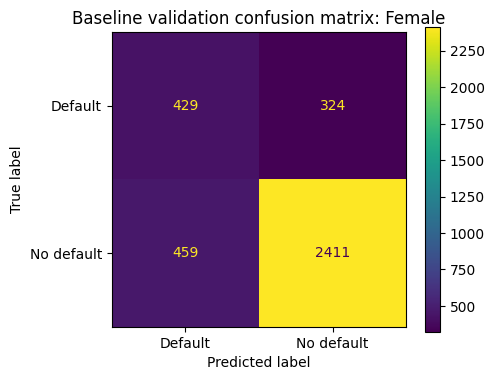

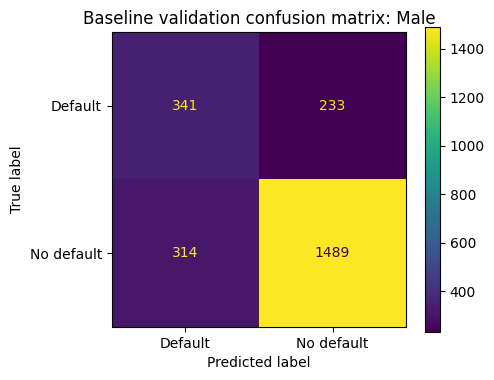

In [44]:
for group_name in sorted(A_val.unique()):
    mask = A_val.to_numpy() == group_name
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_predictions(
        y_val.to_numpy()[mask],
        y_val_pred_baseline[mask],
        display_labels=["Default", "No default"],
        values_format="d",
        ax=ax,
    )
    ax.set_title(f"Baseline validation confusion matrix: {group_name}")
    plt.tight_layout()
    plt.show()


In [45]:
validation_gap_summary = pd.Series({
    "lower_tpr_group": val_by_group["true_positive_rate"].idxmin(),
    "higher_tpr_group": val_by_group["true_positive_rate"].idxmax(),
    "tpr_gap": val_fairness["equal_opportunity_difference"],
    "lower_selection_group": val_by_group["selection_rate"].idxmin(),
    "selection_rate_gap": val_fairness["demographic_parity_difference"],
    "higher_fpr_group": val_by_group["false_positive_rate"].idxmax(),
    "fpr_gap": (
        val_by_group["false_positive_rate"].max()
        - val_by_group["false_positive_rate"].min()
    ),
})
display(validation_gap_summary.to_frame("validation result"))


,validation result
lower_tpr_group,Male
higher_tpr_group,Female
tpr_gap,0.0142
lower_selection_group,Male
selection_rate_gap,0.0305
higher_fpr_group,Female
fpr_gap,0.0244


## Student baseline fairness interpretation required

Use the validation outputs to answer all of the following.

1. Which group has the lower true positive rate and higher false negative rate?
2. Which group has the higher false positive rate?
3. What are the equal opportunity difference, demographic parity difference, and demographic parity ratio?
4. Does the overall performance conceal different group error patterns?
5. Is the disparity practically important enough to motivate intervention? Explain your reasoning without inventing a universal legal threshold.
6. Why does this analysis demonstrate an observed model disparity rather than causal proof that sex produced each decision?


# 10. Mitigation alternatives and selected approach

| Stage | Example | Main benefit | Main limitation |
|---|---|---|---|
| Preprocessing | Reweighing or resampling | Model agnostic and can avoid group specific rules at inference | Alters the effective training distribution and does not guarantee the selected parity condition |
| In processing | Fairness constrained optimisation | Integrates a fairness objective into model training | Adds technical complexity and may restrict estimator choice |
| Post processing | Threshold optimisation | Applies to an existing fitted model and directly targets a selected group metric | Requires sensitive attributes at prediction time and can use group specific or randomised rules |

## Selected approach

The selected method is Fairlearn `ThresholdOptimizer` with true positive rate parity and balanced accuracy as its objective. The baseline model remains fixed. The optimiser learns group specific decision rules from validation data and is then evaluated on the untouched test data.

This method directly addresses the selected allocation harm, but it creates significant deployment concerns. It requires the sensitive attribute when predictions are produced. Exact parity may also require randomisation between thresholds. Group specific decision rules can raise legal, ethical, and governance concerns, so the method is presented as an experimental mitigation rather than a deployment recommendation by itself.

## Student justification required

Explain why true positive rate parity aligns with the chosen harm. Compare this choice with reweighing and in processing constraints. State why the selected method is useful for an empirical study but difficult to deploy in real lending.


# 11. Post processing mitigation

The baseline model was fitted on training data. The post processor now learns its rules from validation data only. The test labels remain unused until the final evaluation.


In [46]:
mitigator = ThresholdOptimizer(
    estimator=baseline_model,
    constraints="true_positive_rate_parity",
    objective="balanced_accuracy_score",
    predict_method="predict_proba",
    prefit=True,
    grid_size=1000,
)

mitigator.fit(
    X_val,
    y_val,
    sensitive_features=A_val,
)

print("Threshold optimisation fitted on validation data.")

if hasattr(mitigator, "interpolated_thresholder_"):
    interpolation_rules = mitigator.interpolated_thresholder_.interpolation_dict
    print(json.dumps(interpolation_rules, default=str, indent=2))


Threshold optimisation fitted on validation data.
{
  "Female": {
    "p0": 0.11189655172413673,
    "operation0": "[>0.557355708743596]",
    "p1": 0.8881034482758633,
    "operation1": "[>0.5162609881179254]"
  },
  "Male": {
    "p0": 0.003610526315789247,
    "operation0": "[>0.5515620704864952]",
    "p1": 0.9963894736842107,
    "operation1": "[>0.5098330337735635]"
  }
}


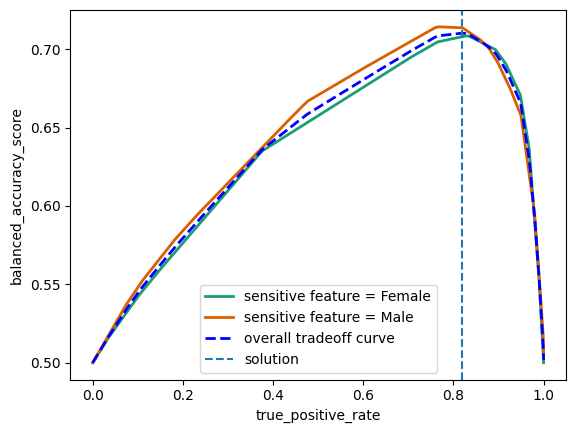

<Figure size 640x480 with 0 Axes>

In [47]:
try:
    plot_threshold_optimizer(mitigator)
    plt.tight_layout()
    plt.show()
except Exception as exc:
    print("Threshold optimiser plot was not available:", exc)


# 12. Final test evaluation

The following cells compare the baseline and mitigated models on the untouched test set. Do not change the model, preprocessing, mitigation constraint, or threshold settings after inspecting these results unless a new untouched test set is created.


In [48]:
y_test_pred_baseline = baseline_model.predict(X_test)
y_test_score_baseline = baseline_model.predict_proba(X_test)[:, 1]

y_test_pred_mitigated = mitigator.predict(
    X_test,
    sensitive_features=A_test,
    random_state=RANDOM_STATE,
)

baseline_predictive = predictive_summary(
    y_test,
    y_test_pred_baseline,
    y_test_score_baseline,
)
mitigated_predictive = predictive_summary(
    y_test,
    y_test_pred_mitigated,
    None,
)

baseline_overall, baseline_by_group, baseline_fairness = fairness_audit(
    y_test,
    y_test_pred_baseline,
    A_test,
)
mitigated_overall, mitigated_by_group, mitigated_fairness = fairness_audit(
    y_test,
    y_test_pred_mitigated,
    A_test,
)

baseline_confusion_counts = confusion_counts_by_group(
    y_test,
    y_test_pred_baseline,
    A_test,
)
mitigated_confusion_counts = confusion_counts_by_group(
    y_test,
    y_test_pred_mitigated,
    A_test,
)

performance_comparison = pd.concat(
    {
        "Baseline": baseline_predictive,
        "Mitigated": mitigated_predictive,
    },
    axis=1,
)
performance_comparison["Change"] = (
    performance_comparison["Mitigated"]
    - performance_comparison["Baseline"]
)

fairness_comparison = pd.concat(
    {
        "Baseline": baseline_fairness,
        "Mitigated": mitigated_fairness,
    },
    axis=1,
)
fairness_comparison["Change"] = (
    fairness_comparison["Mitigated"]
    - fairness_comparison["Baseline"]
)

print("Final performance comparison")
display(performance_comparison)

print("Final scalar fairness comparison")
display(fairness_comparison)

print("Baseline metrics by sensitive group")
display(baseline_by_group)

print("Mitigated metrics by sensitive group")
display(mitigated_by_group)

print("Group metric changes: mitigated minus baseline")
display(mitigated_by_group - baseline_by_group)


Final performance comparison


,Baseline,Mitigated,Change
accuracy,0.7762,0.7647,-0.0115
balanced_accuracy,0.7074,0.7062,-0.0012
precision,0.8755,0.8775,0.0020
recall,0.8307,0.8110,-0.0197
f1,0.8525,0.8430,-0.0096
roc_auc_underlying_estimator,0.7667,NaN,NaN


Final scalar fairness comparison


,Baseline,Mitigated,Change
demographic_parity_difference,0.0204,0.0068,-0.0136
demographic_parity_ratio,0.9726,0.9906,0.0179
equal_opportunity_difference,0.0116,0.0024,-0.0091
equal_opportunity_ratio,0.9862,0.9970,0.0109
equalized_odds_difference,0.0117,0.0239,0.0122


Baseline metrics by sensitive group


,count,observed_no_default_rate,accuracy,balanced_accuracy,selection_rate,true_positive_rate,false_positive_rate,false_negative_rate,precision
SEX_GROUP,,,,,,,,,
Female,3622.0,0.7924,0.7841,0.7121,0.7471,0.8352,0.4109,0.1648,0.8858
Male,2378.0,0.7582,0.7641,0.7005,0.7267,0.8236,0.4226,0.1764,0.8594


Mitigated metrics by sensitive group


,count,observed_no_default_rate,accuracy,balanced_accuracy,selection_rate,true_positive_rate,false_positive_rate,false_negative_rate,precision
SEX_GROUP,,,,,,,,,
Female,3622.0,0.7924,0.7689,0.7109,0.7225,0.8101,0.3883,0.1899,0.8884
Male,2378.0,0.7582,0.7582,0.7002,0.7157,0.8125,0.4122,0.1875,0.8608


Group metric changes: mitigated minus baseline


,count,observed_no_default_rate,accuracy,balanced_accuracy,selection_rate,true_positive_rate,false_positive_rate,false_negative_rate,precision
SEX_GROUP,,,,,,,,,
Female,0.0,0.0,-0.0152,-0.0012,-0.0246,-0.0251,-0.0226,0.0251,0.0026
Male,0.0,0.0,-0.0059,-0.0003,-0.0109,-0.0111,-0.0104,0.0111,0.0014


Baseline confusion counts by group


,TN,FP,FN,TP,records
group,,,,,
Female,443,309,473,2397,3622
Male,332,243,318,1485,2378


Mitigated confusion counts by group


,TN,FP,FN,TP,records
group,,,,,
Female,460,292,545,2325,3622
Male,338,237,338,1465,2378


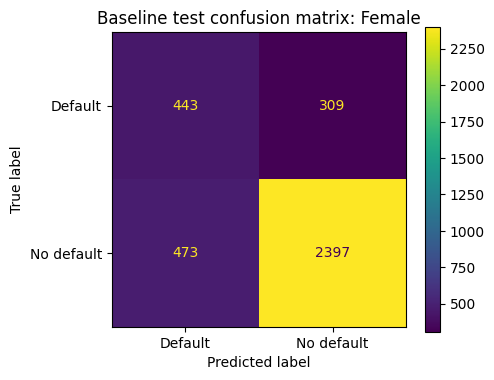

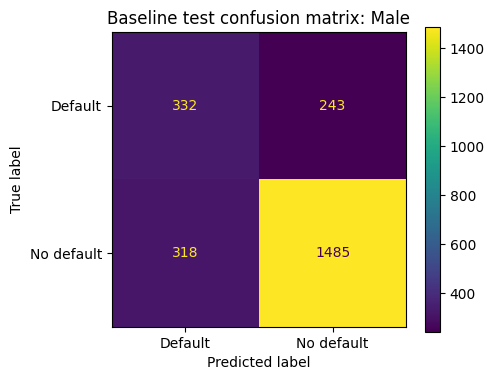

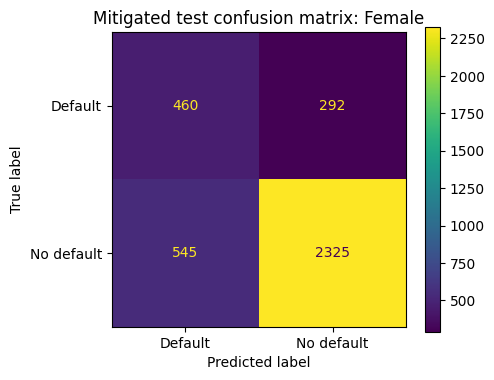

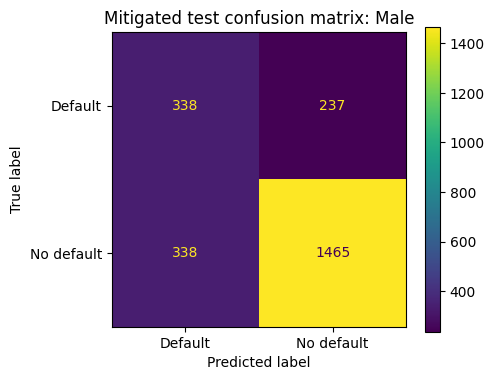

In [49]:
print("Baseline confusion counts by group")
display(baseline_confusion_counts)

print("Mitigated confusion counts by group")
display(mitigated_confusion_counts)

for model_label, predictions in {
    "Baseline": y_test_pred_baseline,
    "Mitigated": y_test_pred_mitigated,
}.items():
    for group_name in sorted(A_test.unique()):
        mask = A_test.to_numpy() == group_name
        fig, ax = plt.subplots(figsize=(5, 4))
        ConfusionMatrixDisplay.from_predictions(
            y_test.to_numpy()[mask],
            predictions[mask],
            display_labels=["Default", "No default"],
            values_format="d",
            ax=ax,
        )
        ax.set_title(f"{model_label} test confusion matrix: {group_name}")
        plt.tight_layout()
        plt.show()


Baseline                                    \
          observed_no_default_rate selection_rate true_positive_rate   
SEX_GROUP                                                              
Female                      0.7924         0.7471             0.8352   
Male                        0.7582         0.7267             0.8236   

                                                                      \
          false_positive_rate false_negative_rate precision accuracy   
SEX_GROUP                                                              
Female                 0.4109              0.1648    0.8858   0.7841   
Male                   0.4226              0.1764    0.8594   0.7641   

                                           Mitigated                 \
          balanced_accuracy observed_no_default_rate selection_rate   
SEX_GROUP                                                             
Female               0.7121                   0.7924         0.7225   
Male                 0.7005                   0.7582         0.7157   

                                                                      \
          true_positive_rate false_positive_rate false_negative_rate   
SEX_GROUP                                                              
Female                0.8101              0.3883              0.1899   
Male                  0.8125              0.4122              0.1875   

                                                
          precision accuracy balanced_accuracy  
SEX_GROUP                                       
Female       0.8884   0.7689            0.7109  
Male         0.8608   0.7582            0.7002

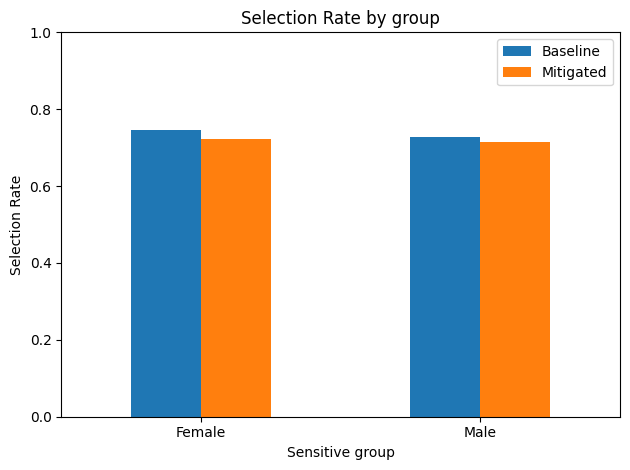

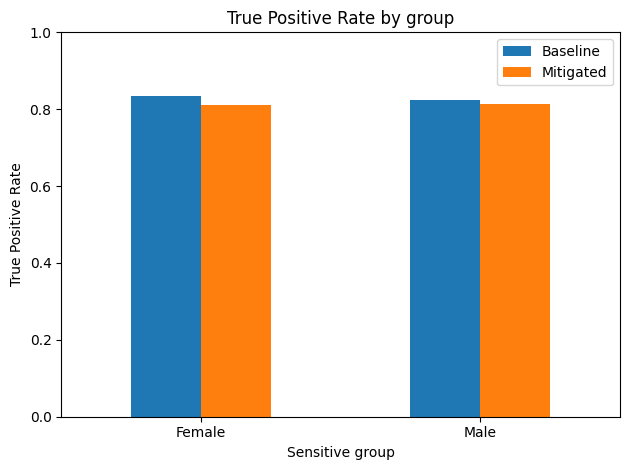

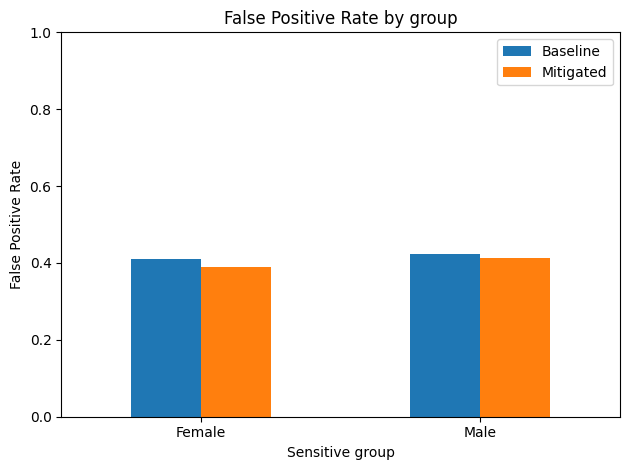

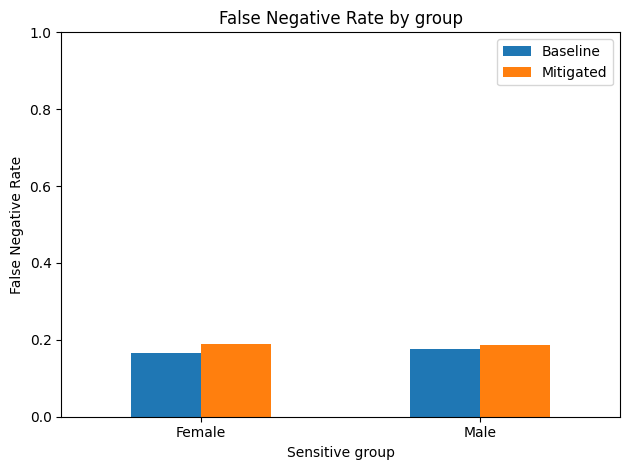

In [50]:
comparison_group_metrics = pd.concat(
    {
        "Baseline": baseline_by_group[[
            "observed_no_default_rate",
            "selection_rate",
            "true_positive_rate",
            "false_positive_rate",
            "false_negative_rate",
            "precision",
            "accuracy",
            "balanced_accuracy",
        ]],
        "Mitigated": mitigated_by_group[[
            "observed_no_default_rate",
            "selection_rate",
            "true_positive_rate",
            "false_positive_rate",
            "false_negative_rate",
            "precision",
            "accuracy",
            "balanced_accuracy",
        ]],
    },
    axis=1,
)
display(comparison_group_metrics)

for metric_name in [
    "selection_rate",
    "true_positive_rate",
    "false_positive_rate",
    "false_negative_rate",
]:
    plot_data = pd.DataFrame({
        "Baseline": baseline_by_group[metric_name],
        "Mitigated": mitigated_by_group[metric_name],
    })
    ax = plot_data.plot(
        kind="bar",
        rot=0,
        title=f"{metric_name.replace('_', ' ').title()} by group",
    )
    ax.set_xlabel("Sensitive group")
    ax.set_ylabel(metric_name.replace("_", " ").title())
    ax.set_ylim(0, 1)
    plt.tight_layout()
    plt.show()


In [51]:
def percentage_point_change(before: float, after: float) -> float:
    return 100 * (after - before)


accuracy_cost_pp = 100 * (
    baseline_predictive["accuracy"]
    - mitigated_predictive["accuracy"]
)
balanced_accuracy_cost_pp = 100 * (
    baseline_predictive["balanced_accuracy"]
    - mitigated_predictive["balanced_accuracy"]
)
equal_opportunity_reduction_pp = 100 * (
    baseline_fairness["equal_opportunity_difference"]
    - mitigated_fairness["equal_opportunity_difference"]
)
dp_reduction_pp = 100 * (
    baseline_fairness["demographic_parity_difference"]
    - mitigated_fairness["demographic_parity_difference"]
)

baseline_tpr_advantaged_group = baseline_by_group["true_positive_rate"].idxmax()
mitigated_tpr_advantaged_group = mitigated_by_group["true_positive_rate"].idxmax()
advantage_reversed = (
    baseline_tpr_advantaged_group != mitigated_tpr_advantaged_group
)

tradeoff_summary = pd.Series({
    "accuracy_cost_percentage_points": accuracy_cost_pp,
    "balanced_accuracy_cost_percentage_points": balanced_accuracy_cost_pp,
    "equal_opportunity_difference_reduction_percentage_points": equal_opportunity_reduction_pp,
    "demographic_parity_difference_reduction_percentage_points": dp_reduction_pp,
    "baseline_equalized_odds_difference": baseline_fairness["equalized_odds_difference"],
    "mitigated_equalized_odds_difference": mitigated_fairness["equalized_odds_difference"],
    "baseline_tpr_advantaged_group": baseline_tpr_advantaged_group,
    "mitigated_tpr_advantaged_group": mitigated_tpr_advantaged_group,
    "tpr_advantage_reversed": advantage_reversed,
})

display(tradeoff_summary.to_frame("value"))


,value
accuracy_cost_percentage_points,1.15
balanced_accuracy_cost_percentage_points,0.1178
equal_opportunity_difference_reduction_percentage_points,0.9134
demographic_parity_difference_reduction_percentage_points,1.3639
baseline_equalized_odds_difference,0.0117
mitigated_equalized_odds_difference,0.0239
baseline_tpr_advantaged_group,Female
mitigated_tpr_advantaged_group,Male
tpr_advantage_reversed,True


In [52]:
results_factsheet = pd.Series({
    "selected_baseline_model": SELECTED_MODEL_NAME,
    "test_records": len(y_test),
    "baseline_accuracy": baseline_predictive["accuracy"],
    "mitigated_accuracy": mitigated_predictive["accuracy"],
    "baseline_balanced_accuracy": baseline_predictive["balanced_accuracy"],
    "mitigated_balanced_accuracy": mitigated_predictive["balanced_accuracy"],
    "baseline_equal_opportunity_difference": baseline_fairness["equal_opportunity_difference"],
    "mitigated_equal_opportunity_difference": mitigated_fairness["equal_opportunity_difference"],
    "baseline_demographic_parity_difference": baseline_fairness["demographic_parity_difference"],
    "mitigated_demographic_parity_difference": mitigated_fairness["demographic_parity_difference"],
    "baseline_demographic_parity_ratio": baseline_fairness["demographic_parity_ratio"],
    "mitigated_demographic_parity_ratio": mitigated_fairness["demographic_parity_ratio"],
    "baseline_equalized_odds_difference": baseline_fairness["equalized_odds_difference"],
    "mitigated_equalized_odds_difference": mitigated_fairness["equalized_odds_difference"],
    "accuracy_cost_percentage_points": accuracy_cost_pp,
    "balanced_accuracy_cost_percentage_points": balanced_accuracy_cost_pp,
})

display(results_factsheet.to_frame("final test value"))

for group_name in baseline_by_group.index:
    print(
        f"{group_name}: baseline TPR {baseline_by_group.loc[group_name, 'true_positive_rate']:.4f}, "
        f"mitigated TPR {mitigated_by_group.loc[group_name, 'true_positive_rate']:.4f}, "
        f"baseline FPR {baseline_by_group.loc[group_name, 'false_positive_rate']:.4f}, "
        f"mitigated FPR {mitigated_by_group.loc[group_name, 'false_positive_rate']:.4f}."
    )


,final test value
selected_baseline_model,logistic_regression
test_records,6000
baseline_accuracy,0.7762
mitigated_accuracy,0.7647
baseline_balanced_accuracy,0.7074
mitigated_balanced_accuracy,0.7062
baseline_equal_opportunity_difference,0.0116
mitigated_equal_opportunity_difference,0.0024
baseline_demographic_parity_difference,0.0204
mitigated_demographic_parity_difference,0.0068


Female: baseline TPR 0.8352, mitigated TPR 0.8101, baseline FPR 0.4109, mitigated FPR 0.3883.
Male: baseline TPR 0.8236, mitigated TPR 0.8125, baseline FPR 0.4226, mitigated FPR 0.4122.


## Student final results interpretation required

Use the final test tables and factsheet. Include exact values and percentage point changes.

1. State baseline and mitigated accuracy and balanced accuracy.
2. State baseline and mitigated equal opportunity difference.
3. Report each group true positive rate before and after mitigation.
4. Report each group false positive rate before and after mitigation.
5. Report demographic parity difference and ratio before and after mitigation.
6. Report equalized odds difference before and after mitigation.
7. Identify the fairness measure that improved most.
8. Identify every important metric that worsened.
9. State the performance cost in percentage points.
10. State whether the group with the higher true positive rate changed after mitigation.
11. Explain whether the mitigation improved the selected fairness objective without implying that every form of unfairness was removed.

Recommended wording is: “The mitigation reduced the measured disparity on this test set.” Avoid claims such as “all bias was eliminated.”


# 13. Robustness analysis

Point estimates can change across samples. The following optional analysis uses a joint group and label stratified bootstrap so every resample preserves the main subgroup structure. The intervals describe uncertainty in the fixed test predictions. They do not account for uncertainty from retraining the entire pipeline on a new sample.


In [53]:
def stratified_bootstrap_indices(
    y_true,
    sensitive,
    rng: np.random.Generator,
) -> np.ndarray:
    y_array = np.asarray(y_true)
    sensitive_array = np.asarray(sensitive)
    joint = np.char.add(
        np.char.add(sensitive_array.astype(str), "_"),
        y_array.astype(str),
    )
    sampled_parts = []
    for stratum in np.unique(joint):
        members = np.flatnonzero(joint == stratum)
        sampled_parts.append(rng.choice(members, size=len(members), replace=True))
    sampled = np.concatenate(sampled_parts)
    rng.shuffle(sampled)
    return sampled


def bootstrap_fairness_interval(
    metric_function: Callable,
    y_true,
    y_pred,
    sensitive,
    n_bootstrap: int = 500,
    random_state: int = RANDOM_STATE,
) -> pd.Series:
    rng = np.random.default_rng(random_state)
    y_array = np.asarray(y_true)
    pred_array = np.asarray(y_pred)
    sensitive_array = np.asarray(sensitive)
    estimates = []

    for _ in range(n_bootstrap):
        indices = stratified_bootstrap_indices(y_array, sensitive_array, rng)
        estimates.append(
            metric_function(
                y_array[indices],
                pred_array[indices],
                sensitive_features=sensitive_array[indices],
            )
        )

    estimates = np.asarray(estimates, dtype=float)
    return pd.Series({
        "estimate": metric_function(
            y_array,
            pred_array,
            sensitive_features=sensitive_array,
        ),
        "lower_95": np.quantile(estimates, 0.025),
        "upper_95": np.quantile(estimates, 0.975),
        "bootstrap_samples": len(estimates),
    })


bootstrap_rows = []
for model_name, predictions in {
    "Baseline": y_test_pred_baseline,
    "Mitigated": y_test_pred_mitigated,
}.items():
    for metric_name, metric_function in {
        "demographic_parity_difference": demographic_parity_difference,
        "equal_opportunity_difference": equal_opportunity_difference,
        "equalized_odds_difference": equalized_odds_difference,
    }.items():
        interval = bootstrap_fairness_interval(
            metric_function,
            y_test,
            predictions,
            A_test,
        )
        interval["model"] = model_name
        interval["metric"] = metric_name
        bootstrap_rows.append(interval)

bootstrap_results = (
    pd.DataFrame(bootstrap_rows)
      .set_index(["model", "metric"])
      .sort_index()
)
display(bootstrap_results)


estimate  lower_95  upper_95  \
model     metric                                                        
Baseline  demographic_parity_difference    0.0204    0.0015    0.0433   
          equal_opportunity_difference     0.0116    0.0005    0.0361   
          equalized_odds_difference        0.0117    0.0059    0.0673   
Mitigated demographic_parity_difference    0.0068    0.0005    0.0304   
          equal_opportunity_difference     0.0024    0.0008    0.0277   
          equalized_odds_difference        0.0239    0.0038    0.0766   

                                         bootstrap_samples  
model     metric                                            
Baseline  demographic_parity_difference              500.0  
          equal_opportunity_difference               500.0  
          equalized_odds_difference                  500.0  
Mitigated demographic_parity_difference              500.0  
          equal_opportunity_difference               500.0  
          equalized_odds_difference                  500.0

## Student robustness interpretation required

State whether the confidence intervals are narrow or wide enough to support a stable conclusion. Note any overlap and explain why a single point estimate should not be treated as certain. Do not describe the intervals as causal evidence.


# 14. Final discussion and recommendations

## Strengths to evaluate

1. The target directly records observed default rather than using income as a proxy.
2. The sensitive attribute is separated from the primary feature matrix.
3. Training, validation, and test data have distinct roles.
4. Candidate models are compared with cross validation.
5. Group confusion matrices and several fairness metrics are reported.
6. The mitigation objective is connected to a defined allocation harm.
7. Preprocessing is contained inside reproducible pipelines.
8. Tradeoffs and worsened metrics are reported rather than hidden.

## Limitations to evaluate

1. No default in one month is not a complete definition of creditworthiness.
2. Historical outcomes may reflect earlier policy, access, and measurement choices.
3. The dataset describes existing customers rather than new applicants.
4. Data from Taiwan in 2005 may not generalise to another market or period.
5. Binary sex coding does not represent gender diversity.
6. Group parity does not guarantee individual fairness.
7. Other protected attributes and intersectional groups are not fully assessed.
8. Threshold optimisation requires sensitive information at prediction time.
9. Group specific and randomised rules create legal and governance concerns.
10. The analysis does not estimate causal discrimination.
11. The model does not include every factor required for affordability or responsible lending.
12. Fairness metrics can conflict, so improving one measure may worsen another.

## Business implications to discuss

1. False negative predictions can unnecessarily restrict customers and lose legitimate business.
2. False positive predictions can increase financial loss and expose customers to unsuitable debt.
3. The institution must decide which tradeoffs are acceptable before deployment.
4. Sensitive information requires strict purpose, access, retention, and security controls.
5. Human review must be meaningful rather than a formal approval step.
6. Customers need understandable reasons, correction mechanisms, and an appeal route.
7. Performance and group disparities require ongoing monitoring after any population, product, policy, or economic change.

## Data driven recommendations

Base the final recommendations on the actual test results. A defensible recommendation set may include:

1. Use the model only for decision support and prioritisation.
2. Route uncertain and high impact cases to trained reviewers.
3. Monitor group true positive, false positive, false negative, precision, and selection rates.
4. Monitor predictive performance and calibration, not fairness metrics alone.
5. Record reviewer overrides and appeal outcomes for audit and error analysis.
6. Review data provenance and the process that created historical labels.
7. Reassess the model after policy, product, population, or economic changes.
8. Conduct legal, compliance, and data protection review before operational use.
9. Compare post processing with less deployment intensive mitigation methods before implementation.
10. Test additional protected and intersectional groups where sample sizes permit.

## Student final discussion required

Write the final discussion in coherent paragraphs rather than copying the lists above. Link each conclusion to an observed result. State what improved, what deteriorated, the performance cost, and why the result remains conditional.

## Conclusion template

Your conclusion should answer the research question in four parts:

1. The baseline disparity observed on validation and test data.
2. The measured effect of true positive rate parity mitigation.
3. The predictive and secondary fairness tradeoffs.
4. The recommended organisational use and controls.


# 15. Model card and reproducibility checklist

## Compact model card

| Field | Documented position |
|---|---|
| Intended use | One month default risk decision support for existing customer review |
| Out of scope | Autonomous approval, pricing, credit limit assignment, or legal compliance determination |
| Dataset | UCI Default of Credit Card Clients, 30,000 records, Taiwan, 2005 |
| Target | No default in the following month equals the favourable class |
| Sensitive attribute | Sex as coded by the source dataset |
| Primary fairness harm | Incorrect unfavourable prediction for an observed no default customer |
| Primary fairness metric | Equal opportunity difference |
| Mitigation | Threshold optimisation with true positive rate parity |
| Principal deployment limitation | Sensitive group information and group specific, potentially randomised rules are required at prediction time |
| Human oversight | Required for review, explanation, correction, and appeal |

## Reproducibility checklist

Before submission, confirm every item.

1. The dataset was not used in the module exercises.
2. The dataset URL and DOI are included.
3. The positive label and sensitive attribute are clearly defined.
4. The protected attribute is absent from the primary feature matrix.
5. Train, validation, and test roles are documented.
6. Preprocessing is fitted only inside model pipelines.
7. Candidate models are compared using training data only.
8. The selected model is justified.
9. Group counts and confusion matrices are shown.
10. The primary fairness metric is connected to a specific harm.
11. Preprocessing, in processing, and post processing alternatives are discussed.
12. The mitigation is fitted without test labels.
13. Baseline and mitigated results appear in the same tables.
14. Performance costs and worsened fairness metrics are reported.
15. No result is presented as proof of complete fairness or legal compliance.
16. Every number in the written discussion matches the executed output.
17. All cells run in order from a clean restart.
18. Failed installation output, warnings, and exploratory scratch cells are removed.
19. The repository includes the notebook, requirements, README, and data access instructions.
20. The repository is not changed after the submission deadline.


# 16. References

Use the citation style required by the university. The following entries are suitable starting points and should be checked against the required format.

1. Barocas, S., Hardt, M. and Narayanan, A. (2023) *Fairness and Machine Learning: Limitations and Opportunities*. Available at: https://fairmlbook.org/
2. Bird, S. et al. (2020) ‘Fairlearn: A toolkit for assessing and improving fairness in AI’, Microsoft. Available at: https://fairlearn.org/
3. Chouldechova, A. (2017) ‘Fair prediction with disparate impact: A study of bias in recidivism prediction instruments’, *Big Data*, 5(2), pp. 153 to 163.
4. Fairlearn contributors (2026) *Fairlearn 0.14.0 documentation*. Available at: https://fairlearn.org/v0.14/
5. Hardt, M., Price, E. and Srebro, N. (2016) ‘Equality of opportunity in supervised learning’, *Advances in Neural Information Processing Systems*, 29.
6. Kleinberg, J., Mullainathan, S. and Raghavan, M. (2017) ‘Inherent tradeoffs in the fair determination of risk scores’, *Proceedings of the 8th Innovations in Theoretical Computer Science Conference*.
7. Pedregosa, F. et al. (2011) ‘Scikit learn: Machine learning in Python’, *Journal of Machine Learning Research*, 12, pp. 2825 to 2830.
8. Yeh, I. C. (2009) *Default of Credit Card Clients* [Dataset]. UCI Machine Learning Repository. doi: 10.24432/C55S3H.
9. Relevant M515A lecture material used for ethical principles, discrimination definitions, and mitigation methods.

Do not cite a source that you have not read. Add access dates when required by the university style guide.
